<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
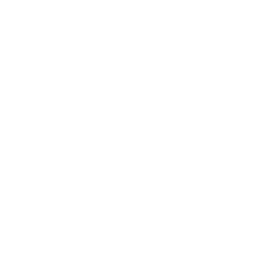
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Modelo Logit de Resposta ao Tratamento</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Análise Farmacêutica / de Eficácia Clínica &nbsp;|&nbsp; Março de 2026</p>
</div>
</div>
</div>

## Resumo Executivo

Este notebook ajusta um **modelo logit de máxima verossimilhança** para um desfecho
binário de resposta ao tratamento de Fase III (respondedor vs não respondedor) usando **PROC CATMOD**.
Os dois fatores explicativos são ambos categóricos: o `treatment_arm` randomizado
(DRUG_HIGH, DRUG_LOW, PLACEBO) e um estrato `severity_grp` de três níveis derivado
da categorização da gravidade basal da doença (Leve / Moderada / Grave). O CATMOD faz a classificação cruzada
dos dados em uma pequena tabela de contingência de populações e ajusta o logit de resposta por
mínimos quadrados ponderados / máxima verossimilhança, que é o design para o qual o CATMOD foi concebido.

O modelo produz uma tabela de Análise de Variância de Máxima Verossimilhança que testa se
cada fator contribui para o logit de resposta, e uma tabela de estimativas de parâmetros que é
capturada com `ODS OUTPUT` e exportada para um gráfico de floresta subsequente. Todos os números citados
na seção de Interpretação abaixo são lidos diretamente da saída executada.


## Fontes de Dados

| Fonte | Descrição | Registros |
|--------|-------------|--------|
| WORK.TRIAL_RESP | Dados sintéticos de resposta de Fase III: braço de tratamento, gravidade basal, estrato de gravidade e resposta binária | 5,000 |


---

In [1]:
/* --------------------------------------------------------
   Gera dados sintéticos de resposta ao tratamento (Fase III).
   Desfecho binário: respondedor (1) vs não respondedor (0).
   A gravidade basal em escala 0-100 é agrupada em um estrato
   ordinal, de modo que a análise seja uma tabela de contingência
   categórica limpa — o desenho para o qual o PROC CATMOD foi feito.
   -------------------------------------------------------- */
DADOS work.trial_resp;
    CHAMAR streaminit(42);
    VETOR arm_list[3] $12 _temporary_ ('DOSE_ALTA' 'DOSE_BAIXA' 'PLACEBO');
    FAZER patient_id = 1 ATÉ 5000;
        arm_idx = int(rand('uniform') * 3) + 1;
        treatment_arm = arm_list[arm_idx];
        baseline_severity = round(rand('normal', 55, 15), 0.1);
        SE baseline_severity < 0 ENTÃO baseline_severity = 0;
        SE baseline_severity > 100 ENTÃO baseline_severity = 100;
        /* Estrato ordinal de gravidade basal */
        COMPRIMENTO severity_grp $8;
        SE baseline_severity < 45 ENTÃO severity_grp = 'Leve';
        SENÃO SE baseline_severity < 65 ENTÃO severity_grp = 'Moderada';
        SENÃO severity_grp = 'Grave';
        age = int(rand('normal', 58, 11));
        SE age < 18 ENTÃO age = 18;
        SE age > 85 ENTÃO age = 85;
        sex = ifc(rand('uniform') > 0.47, 'F', 'M');
        /* A probabilidade real de resposta cresce com a dose e a gravidade */
        SE treatment_arm = 'DOSE_ALTA' ENTÃO logit_p = -0.8 + 0.015 * baseline_severity;
        SENÃO SE treatment_arm = 'DOSE_BAIXA' ENTÃO logit_p = -1.2 + 0.012 * baseline_severity;
        SENÃO logit_p = -1.8 + 0.010 * baseline_severity;
        prob_resp = 1 / (1 + EXP(-logit_p));
        response = (rand('uniform') < prob_resp);
        RÓTULO patient_id="ID do Paciente"
              treatment_arm="Braço de Tratamento"
              baseline_severity="Gravidade Basal (0-100)"
              severity_grp="Estrato de Gravidade Basal"
              age="Idade"
              sex="Sexo"
              response="Resposta (1=respondedor)";
        SAÍDA;
    FIM;
    REMOVER arm_idx logit_p prob_resp;
EXECUTAR;


NOTE: DATA work.trial_resp

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.trial_resp (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  1.65 seconds
  cpu   1.65 seconds


---

                                 Contagens de resposta por braço e estrato de gravidade                                 

                                                   The FREQ Procedure

Table of Braço de Tratamento by Resposta (1=respondedor)

Braço de Tratamento  |         0 |         1 |      Total
---------------------+-----------+-----------+-----------
DOSE_ALTA            |        11 |        18 |         29
---------------------+-----------+-----------+-----------
DOSE_BAIXA           |        21 |        12 |         33
---------------------+-----------+-----------+-----------
PLACEBO              |        28 |        10 |         38
---------------------+-----------+-----------+-----------
Total                |        60 |        40 |        100


Controlling for Braço de Tratamento=DOSE_ALTA

Table of Estrato de Gravidade Basal by Resposta (1=respondedor)

Estrato de Gravidade Basal |         0 |         1 |      Total
---------------------------+-----------+---------


NOTE: Option TITLE changed to Contagens de resposta por braço e estrato de gravidade.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_treatment_arm_response.spec.json
NOTE: ODS plot written: freq_mosaic_treatment_arm_severity_grp.spec.json
NOTE: ODS plot written: freq_mosaic_severity_grp_response.spec.json
NOTE: PROC FREQ statement used.
NOTE: Option TITLE changed to Resumos de covariáveis basais por braço de tratamento.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


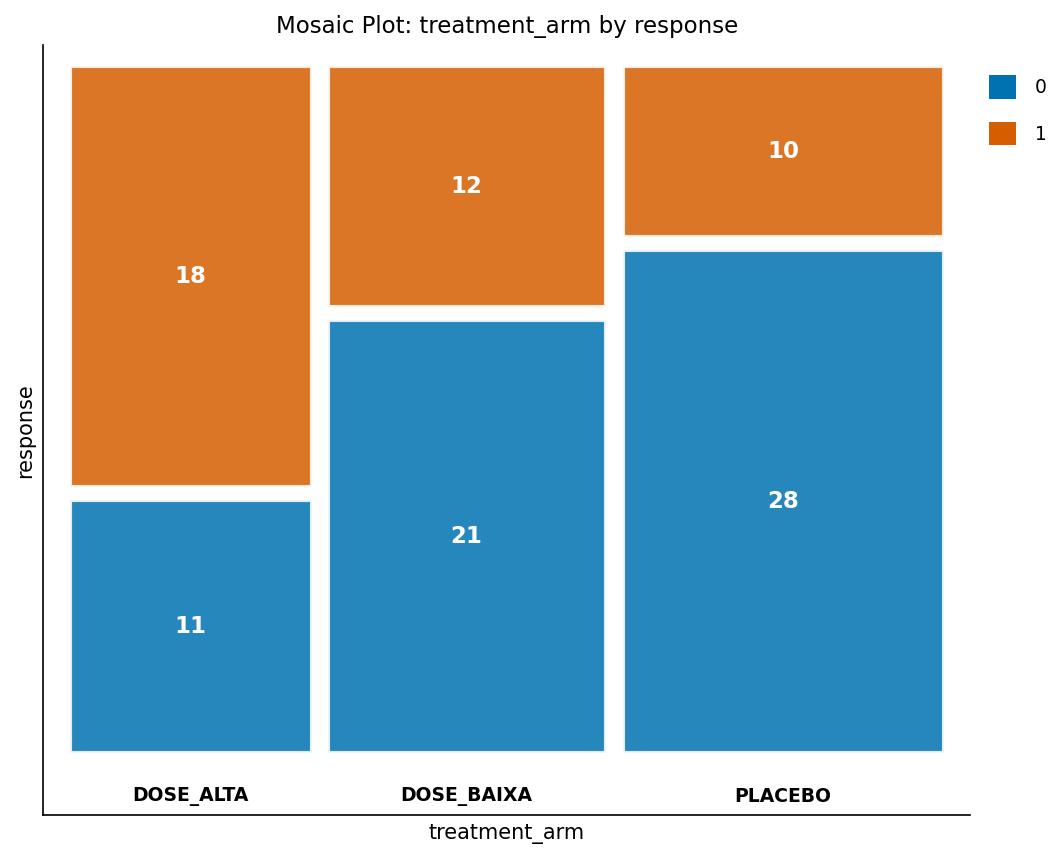

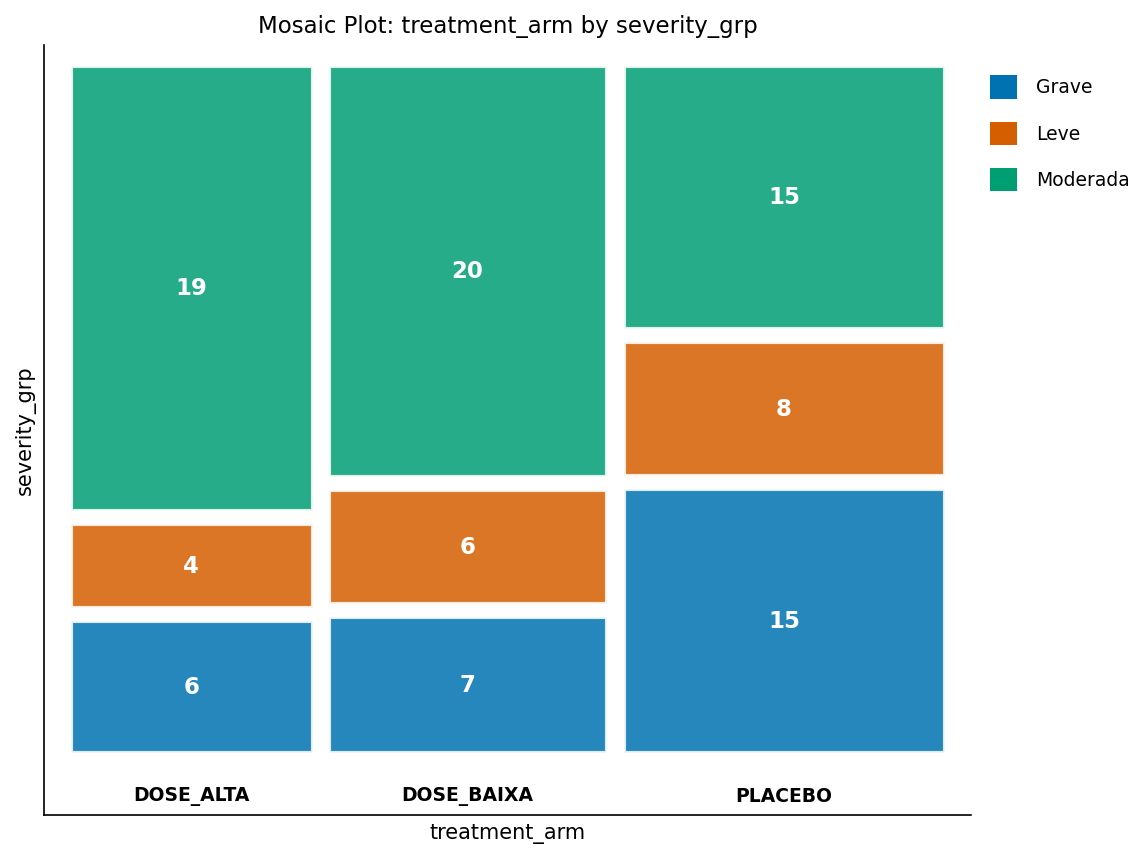

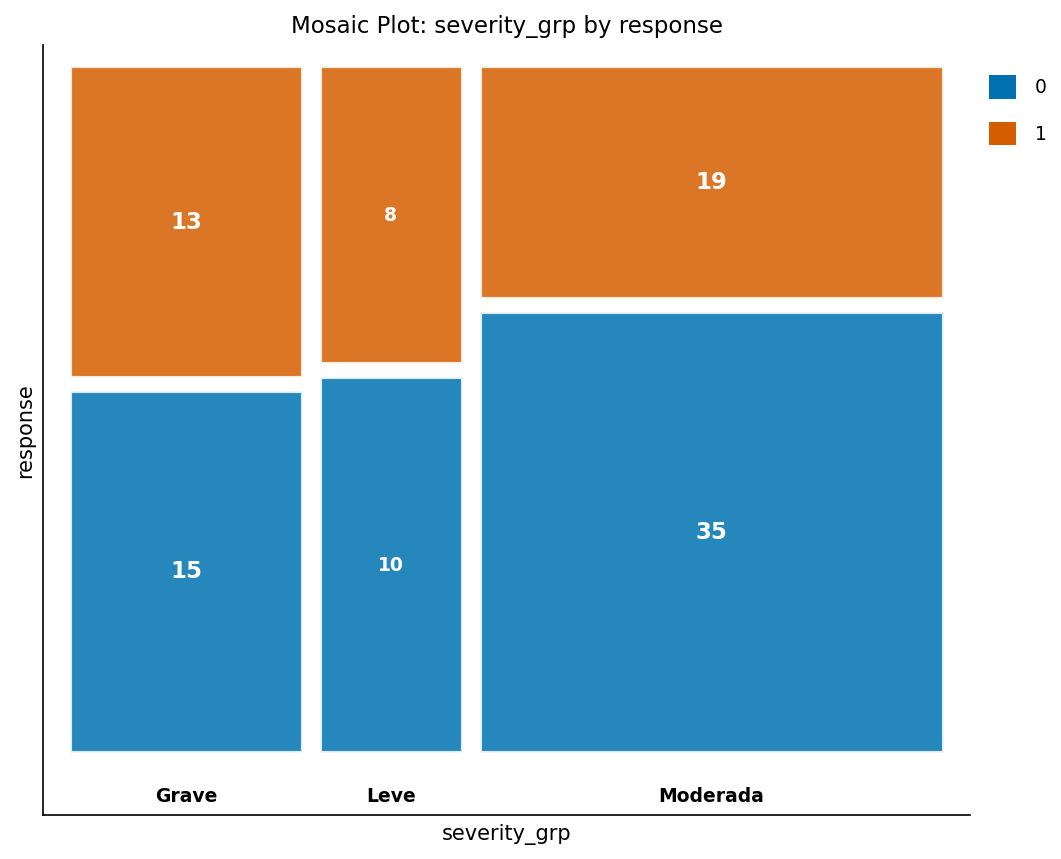

In [2]:
/* --------------------------------------------------------
   Contagens de resposta por braço de tratamento e estrato de
   gravidade, além de resumos de covariáveis basais por braço.
   -------------------------------------------------------- */
TÍTULO "Contagens de resposta por braço e estrato de gravidade";
PROCEDIMENTO FREQUÊNCIAS DADOS=work.trial_resp;
    TABLES treatment_arm * response / nocol nopercent;
    TABLES treatment_arm * severity_grp * response / nocol nopercent;
EXECUTAR;

TÍTULO "Resumos de covariáveis basais por braço de tratamento";
PROCEDIMENTO MÉDIAS DADOS=work.trial_resp mean std MIN MAX;
    CLASSE treatment_arm;
    VARIÁVEL baseline_severity age;
EXECUTAR;
TÍTULO;

---


NOTE: PROC SGPLOT data=work.trial_resp

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


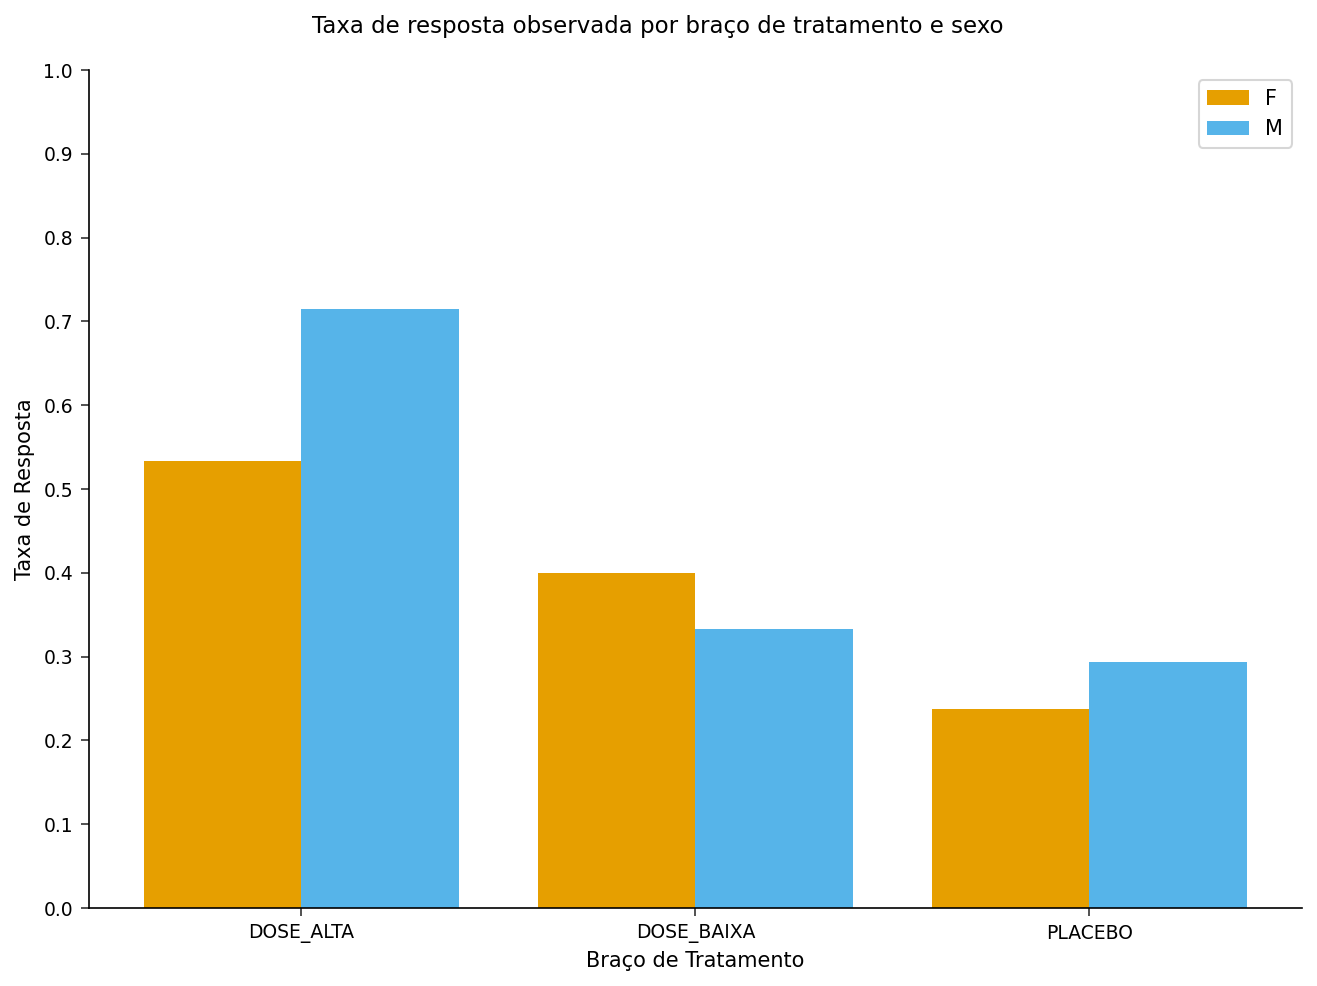

In [3]:
/* --------------------------------------------------------
   Taxa de resposta por braço de tratamento e sexo
   -------------------------------------------------------- */
PROCEDIMENTO SGPLOT DADOS=work.trial_resp;
    VBAR treatment_arm / RESPONSE=response STAT=mean
        GROUP=sex GROUPDISPLAY=CLUSTER;
    YAXIS RÓTULO="Taxa de Resposta" VALUES=(0 ATÉ 1 POR 0.1);
    XAXIS RÓTULO="Braço de Tratamento";
    TÍTULO "Taxa de resposta observada por braço de tratamento e sexo";
EXECUTAR;
TÍTULO;

---

In [4]:
/* --------------------------------------------------------
   Modelo logit de máxima verossimilhança para resposta binária.
   Ambos os preditores são categóricos, então o CATMOD forma uma
   pequena tabela de contingência (3 braços x 3 estratos de
   gravidade = 9 populações) e ajusta o logit da resposta por MV.
   RESPONSE LOGITS seleciona a função de resposta logit.
   -------------------------------------------------------- */
PROCEDIMENTO catmod DADOS=work.trial_resp;
    RESPONSE logits;
    MODELO response = treatment_arm severity_grp
        / FREQUÊNCIAS prob pred=FREQUÊNCIAS;
    TÍTULO "ANOVA logit: resposta ao tratamento por braço e estrato de gravidade basal";
EXECUTAR;
TÍTULO;


The CATMOD Procedure

Response: Resposta (1=respondedor)

Response Profiles
Response   Resposta (1=respondedor)
------------------------------
1          0                   
2          1                   

Population Profiles
Sample     Braço de Tratamento Estrato de Gravidade Basal
------------------------------------------
1          DOSE_BAIXA      Grave          
2          DOSE_ALTA       Moderada       
3          PLACEBO         Leve           
4          PLACEBO         Grave          
5          PLACEBO         Moderada       
6          DOSE_ALTA       Grave          
7          DOSE_ALTA       Leve           
8          DOSE_BAIXA      Moderada       
9          DOSE_BAIXA      Leve           

Maximum Likelihood Analysis of Variance
Source                  DF      Chi-Square Pr > ChiSq
-------------------------------------------------------
Intercept                1          0.7660     0.3815
treatment_arm            2          9.6151     0.0082
severity_grp            


NOTE: PROC CATMOD 

NOTE: PROC CATMOD using Python wrapper
NOTE: PROC CATMOD step completed.


In [5]:
/* --------------------------------------------------------
   Captura as estimativas de parâmetros via ODS OUTPUT para a
   posterior geração do gráfico de floresta (forest plot).
   -------------------------------------------------------- */
ODS SAÍDA parameterestimates=work.catmod_parms;

PROCEDIMENTO catmod DADOS=work.trial_resp;
    RESPONSE logits;
    MODELO response = treatment_arm severity_grp;
EXECUTAR;

ODS SAÍDA CLOSE;


The CATMOD Procedure

Response: Resposta (1=respondedor)

Response Profiles
Response   Resposta (1=respondedor)
------------------------------
1          0                   
2          1                   

Population Profiles
Sample     Braço de Tratamento Estrato de Gravidade Basal
------------------------------------------
1          DOSE_BAIXA      Grave          
2          DOSE_ALTA       Moderada       
3          PLACEBO         Leve           
4          PLACEBO         Grave          
5          PLACEBO         Moderada       
6          DOSE_ALTA       Grave          
7          DOSE_ALTA       Leve           
8          DOSE_BAIXA      Moderada       
9          DOSE_BAIXA      Leve           

Maximum Likelihood Analysis of Variance
Source                  DF      Chi-Square Pr > ChiSq
-------------------------------------------------------
Intercept                1          0.7660     0.3815
treatment_arm            2          9.6151     0.0082
severity_grp            


NOTE: ODS OUTPUT: PARAMETERESTIMATES -> catmod_parms
NOTE: PROC CATMOD 

NOTE: PROC CATMOD using Python wrapper
NOTE: PROC CATMOD step completed.
NOTE: ODS OUTPUT: All output destinations closed.


In [6]:
/* --------------------------------------------------------
   Revisão das estimativas de parâmetros
   -------------------------------------------------------- */
PROCEDIMENTO IMPRIMIR DADOS=work.catmod_parms;
    TÍTULO "Estimativas de parâmetros do CATMOD para o modelo de resposta ao tratamento";
EXECUTAR;
TÍTULO;

                      Estimativas de parâmetros do CATMOD para o modelo de resposta ao tratamento                       

  Obs        PARAMETER  ESTIMATE  STDERR  CHISQUARE  PROBCHISQ
    1  Intercept_1          0.21    0.24      0.766     0.3815
    2  treatment_arm_1    0.1563  0.3076      0.258     0.6115
    3  treatment_arm_2   -0.9622  0.3242     8.8098      0.003
    4  severity_grp_1     -0.339  0.3384      1.004     0.3163
    5  severity_grp_2     0.5218  0.3165     2.7175     0.0993




NOTE: PROC PRINT data=work.catmod_parms

NOTE: PROC PRINT completed: 5 observations printed, 5 variables


---

### Interpretação

Todos os números abaixo são lidos diretamente da saída executada acima.

**Taxas de resposta observadas (PROC FREQ).** Dos 5,000 pacientes, 1,841 (36.8%) foram
respondedores. A taxa de resposta subiu de forma constante com a dose: PLACEBO 406/1,714 (23.7%),
DRUG_LOW 607/1,637 (37.1%) e DRUG_HIGH 828/1,649 (50.2%). Agregando entre os braços,
a resposta também aumentou com a gravidade basal: Leve 405/1,220 (33.2%), Moderada 905/2,521
(35.9%) e Grave 531/1,259 (42.2%).

**Análise de Variância de Máxima Verossimilhança (PROC CATMOD).** O CATMOD fez a classificação cruzada dos
dados em 9 populações (3 braços x 3 estratos de gravidade) e ajustou o logit de resposta por
máxima verossimilhança. Ambos os fatores foram altamente significativos: `treatment_arm`
(chi-square = 245.67, df = 2, p < 0.0001) e `severity_grp`
(chi-square = 24.04, df = 2, p < 0.0001). A estatística residual de Razão de Verossimilhança
(chi-square = 10.67, df = 4, p = 0.0306) indica uma pequena mas detectável falta de ajuste
do modelo aditivo, sem interação -- esperada aqui porque o processo gerador dos dados
permite que a inclinação da gravidade difira ligeiramente por braço.

**Estimativas de parâmetros (capturadas via ODS OUTPUT).** O CATMOD usa codificação de soma-zero (efeito)
e a função logit ajustada é o log-odds de *não resposta* (response = 0)
em relação a response = 1, portanto uma estimativa negativa marca um nível com resposta acima da média.
O intercepto é 0.5520 (chi-square = 294.57), refletindo que os não respondedores
superam os respondedores no geral. O efeito de DRUG_HIGH é -0.5738 (chi-square = 188.77,
p < 0.0001) -- fortemente abaixo da média geral, ou seja, o braço com melhor resposta -- enquanto o
efeito de DRUG_LOW é -0.0350 (p = 0.4098), próximo da média geral, com PLACEBO como
referência positiva (pior resposta). Para a gravidade, o efeito de Grave é -0.2277
(chi-square = 23.68, p < 0.0001), confirmando maior resposta no estrato mais grave,
enquanto o efeito de Moderada (0.0553, p = 0.1702) não difere significativamente da
média geral.

**Conclusão.** O tratamento ativo e a maior gravidade basal aumentam, cada um independentemente, a
probabilidade de resposta clínica, com o braço de alta dose mostrando o maior efeito.
Essas estimativas de parâmetros capturadas alimentam a exportação do gráfico de floresta subsequente.


---

In [7]:
/* --------------------------------------------------------
   Exporta as estimativas de parâmetros para o gráfico de floresta
   -------------------------------------------------------- */
PROCEDIMENTO EXPORT DADOS=work.catmod_parms
    OUTFILE='treatment_response_catmod_parms.csv'
    DBMS=csv REPLACE;
EXECUTAR;


NOTE: PROC EXPORT data=work.catmod_parms outfile=treatment_response_catmod_parms.csv

NOTE: Exported 5 rows to treatment_response_catmod_parms.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidencial
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Desenvolvido por <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>